<a href="https://www.kaggle.com/code/nischalgirii/xgboost-classification?scriptVersionId=313795450" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [55]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chris72407/supplier-risk-classification-dataset/supplier_risk_dataset.csv


# **Supplier Risk Classification Dataset**

# 1) Problem Statement
   Build a machine learning model to classify suppliers into risk categories (e.g., High, Medium, Low) based on their operational and performance features.
   

# 2) Data Collection
The dataset is collected from 
https://www.kaggle.com/datasets/chris72407/supplier-risk-classification-dataset/data. It consist of 27388 rows and 11 columns

In [56]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [57]:
df= pd.read_csv("/kaggle/input/datasets/chris72407/supplier-risk-classification-dataset/supplier_risk_dataset.csv")
df.head()

,Supplier_ID,Financial_Stability_Score,On_Time_Delivery_Rate,Defect_Rate,Geopolitical_Risk_Index,Lead_Time_Days,Alternative_Suppliers_Available,Contract_Length_Months,Environmental_Compliance,Previous_Disruptions,Risk_Level
0,SUP_30248,95.69,100.00,2.59,52,31.0,3.0,17,48.80,2.0,0
1,SUP_23186,78.32,93.90,5.92,18,7.0,0.0,33,45.19,0.0,1
2,SUP_29736,58.98,100.00,0.00,45,51.0,0.0,10,48.01,2.0,1
3,SUP_27251,68.64,61.83,3.32,41,60.0,4.0,11,84.34,0.0,0
4,SUP_25660,98.93,100.00,1.07,41,31.0,3.0,42,64.41,1.0,0


In [58]:
df.info

<bound method DataFrame.info of       Supplier_ID  Financial_Stability_Score  On_Time_Delivery_Rate  \
0       SUP_30248                      95.69                 100.00   
1       SUP_23186                      78.32                  93.90   
2       SUP_29736                      58.98                 100.00   
3       SUP_27251                      68.64                  61.83   
4       SUP_25660                      98.93                 100.00   
...           ...                        ...                    ...   
27383   SUP_00140                      75.93                  92.93   
27384   SUP_00356                      77.09                  77.97   
27385   SUP_05612                      71.65                  72.61   
27386   SUP_20011                      65.43                  76.76   
27387   SUP_04445                      65.22                  75.73   

       Defect_Rate  Geopolitical_Risk_Index  Lead_Time_Days  \
0             2.59                       52         

DATA CLEANING

* Handling Missing Values
* Handling Duplicates
* Check Data Type
* Understand the Dataset

In [59]:
# Check missing values
df.isnull().sum()

Supplier_ID                          0
Financial_Stability_Score          395
On_Time_Delivery_Rate              221
Defect_Rate                        316
Geopolitical_Risk_Index              0
Lead_Time_Days                     235
Alternative_Suppliers_Available    263
Contract_Length_Months               0
Environmental_Compliance           370
Previous_Disruptions               206
Risk_Level                           0
dtype: int64

In [60]:
df.isnull().mean() * 100

Supplier_ID                        0.000000
Financial_Stability_Score          1.442237
On_Time_Delivery_Rate              0.806923
Defect_Rate                        1.153790
Geopolitical_Risk_Index            0.000000
Lead_Time_Days                     0.858040
Alternative_Suppliers_Available    0.960275
Contract_Length_Months             0.000000
Environmental_Compliance           1.350957
Previous_Disruptions               0.752154
Risk_Level                         0.000000
dtype: float64

here missing value is less than 5%. So, filling the missing value with median

In [61]:
num_cols = [
    'Financial_Stability_Score',
    'On_Time_Delivery_Rate',
    'Defect_Rate',
    'Lead_Time_Days',
    'Alternative_Suppliers_Available',
    'Environmental_Compliance',
    'Previous_Disruptions'
]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

<Axes: ylabel='Lead_Time_Days'>

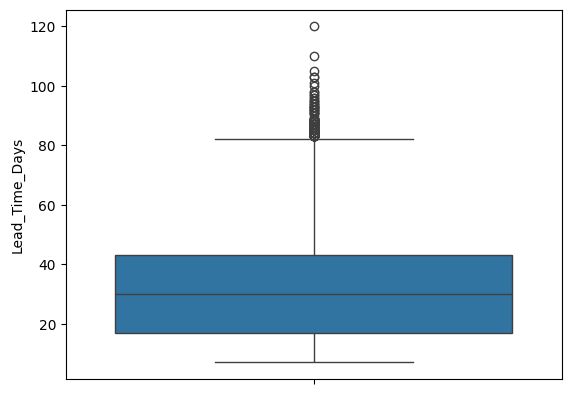

In [62]:
sns.boxplot(df['Lead_Time_Days'])

checking for outliers

In [63]:
df.head()

,Supplier_ID,Financial_Stability_Score,On_Time_Delivery_Rate,Defect_Rate,Geopolitical_Risk_Index,Lead_Time_Days,Alternative_Suppliers_Available,Contract_Length_Months,Environmental_Compliance,Previous_Disruptions,Risk_Level
0,SUP_30248,95.69,100.00,2.59,52,31.0,3.0,17,48.80,2.0,0
1,SUP_23186,78.32,93.90,5.92,18,7.0,0.0,33,45.19,0.0,1
2,SUP_29736,58.98,100.00,0.00,45,51.0,0.0,10,48.01,2.0,1
3,SUP_27251,68.64,61.83,3.32,41,60.0,4.0,11,84.34,0.0,0
4,SUP_25660,98.93,100.00,1.07,41,31.0,3.0,42,64.41,1.0,0


In [64]:
df =df.drop('Supplier_ID', axis=1)


In [65]:
df.head()

,Financial_Stability_Score,On_Time_Delivery_Rate,Defect_Rate,Geopolitical_Risk_Index,Lead_Time_Days,Alternative_Suppliers_Available,Contract_Length_Months,Environmental_Compliance,Previous_Disruptions,Risk_Level
0,95.69,100.00,2.59,52,31.0,3.0,17,48.80,2.0,0
1,78.32,93.90,5.92,18,7.0,0.0,33,45.19,0.0,1
2,58.98,100.00,0.00,45,51.0,0.0,10,48.01,2.0,1
3,68.64,61.83,3.32,41,60.0,4.0,11,84.34,0.0,0
4,98.93,100.00,1.07,41,31.0,3.0,42,64.41,1.0,0


Train Test Split and Model Training

In [66]:
from sklearn.model_selection import train_test_split
X = df.drop(['Risk_Level'], axis=1)
y = df['Risk_Level']

In [67]:
X.head()

,Financial_Stability_Score,On_Time_Delivery_Rate,Defect_Rate,Geopolitical_Risk_Index,Lead_Time_Days,Alternative_Suppliers_Available,Contract_Length_Months,Environmental_Compliance,Previous_Disruptions
0,95.69,100.00,2.59,52,31.0,3.0,17,48.80,2.0
1,78.32,93.90,5.92,18,7.0,0.0,33,45.19,0.0
2,58.98,100.00,0.00,45,51.0,0.0,10,48.01,2.0
3,68.64,61.83,3.32,41,60.0,4.0,11,84.34,0.0
4,98.93,100.00,1.07,41,31.0,3.0,42,64.41,1.0


In [69]:
y.value_counts()

Risk_Level
1    19174
0     8214
Name: count, dtype: int64

In [70]:
# Separate the dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [72]:
X_train.shape, X_test.shape

((21910, 9), (5478, 9))

In [73]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27388 entries, 0 to 27387
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Financial_Stability_Score        27388 non-null  float64
 1   On_Time_Delivery_Rate            27388 non-null  float64
 2   Defect_Rate                      27388 non-null  float64
 3   Geopolitical_Risk_Index          27388 non-null  int64  
 4   Lead_Time_Days                   27388 non-null  float64
 5   Alternative_Suppliers_Available  27388 non-null  float64
 6   Contract_Length_Months           27388 non-null  int64  
 7   Environmental_Compliance         27388 non-null  float64
 8   Previous_Disruptions             27388 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 1.9 MB


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
pd.DataFrame(X_train).head()

,Financial_Stability_Score,On_Time_Delivery_Rate,Defect_Rate,Geopolitical_Risk_Index,Lead_Time_Days,Alternative_Suppliers_Available,Contract_Length_Months,Environmental_Compliance,Previous_Disruptions
8248,86.47,82.72,3.85,47,41.0,4.0,39,78.71,2.0
22536,57.11,96.46,6.49,64,13.0,3.0,6,62.66,1.0
3244,69.06,100.00,0.20,23,32.0,0.0,18,64.37,1.0
4957,63.97,74.23,0.00,27,19.0,1.0,33,63.01,0.0
15548,63.49,93.19,0.00,22,50.0,4.0,28,68.21,1.0


XgBoost Classifier Training 


In [78]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [79]:
models = {
    "XGBClassifier": XGBClassifier(),
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train the model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    mode_train_accuracy = accuracy_score(y_train, y_train_pred) # calculate accuracy
    model_train_f1 = f1_score(y_train, y_train_pred) # calculate f1 score
    model_train_precision = precision_score(y_train, y_train_pred) # calculate precision
    model_train_recall = recall_score(y_train, y_train_pred) # calculate recall
    model_train_roc_auc = roc_auc_score(y_train, y_train_pred) # calculate roc_auc

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # calculate accuracy
    model_test_f1 = f1_score(y_test, y_test_pred) # calculate f1 score
    model_test_precision = precision_score(y_test, y_test_pred) # calculate precision
    model_test_recall = recall_score(y_test, y_test_pred) # calculate recall
    model_test_roc_auc = roc_auc_score(y_test, y_test_pred) # calculate roc_auc

    print(f"Model: {list(models.keys())[i]}")

    print("Training set performance")
    print("Accuracy: {:.4f}".format(mode_train_accuracy))
    print("F1 Score: {:.4f}".format(model_train_f1))
    print("Precision: {:.4f}".format(model_train_precision))
    print("Recall: {:.4f}".format(model_train_recall))
    print("ROC AUC: {:.4f}".format(model_train_roc_auc))

    print("\nTest set performance")
    print("Accuracy: {:.4f}".format(model_test_accuracy))
    print("F1 Score: {:.4f}".format(model_test_f1))
    print("Precision: {:.4f}".format(model_test_precision))
    print("Recall: {:.4f}".format(model_test_recall))
    print("ROC AUC: {:.4f}\n".format(model_test_roc_auc))

Model: XGBClassifier
Training set performance
Accuracy: 0.9978
F1 Score: 0.9984
Precision: 0.9985
Recall: 0.9983
ROC AUC: 0.9974

Test set performance
Accuracy: 0.9675
F1 Score: 0.9770
Precision: 0.9675
Recall: 0.9867
ROC AUC: 0.9549



In [80]:
# Hyperparameter tuning
xb_params = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7 , 15, 30],
    'n_estimators': [100, 200, 500, 1000],
    'colsample_bytree': [0.3, 0.5, 0.7, 1]
}

In [81]:
xb_params

{'learning_rate': [0.01, 0.1, 0.3],
 'max_depth': [3, 5, 7, 15, 30],
 'n_estimators': [100, 200, 500, 1000],
 'colsample_bytree': [0.3, 0.5, 0.7, 1]}

In [85]:
# Models list for hyperparameter tuning
randomcv_models = [
    ('XGBClassifier', XGBClassifier(), xb_params)
]

In [86]:
randomcv_models

[('XGBClassifier',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...),
  {'learning_rate': [0.01, 0.1, 0.3],
   'max_depth': [3, 5, 7, 15, 30],
   'n_estimators': [100, 200, 500, 1000],
   'colsample_bytree': [0.3, 0.5, 0.7, 1]})]

For better hyperparameter testing use GridSearchCV

In [87]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}

for name, model, param in randomcv_models:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=xb_params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1
    )
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"------------------Best Parameters for {model_name}------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END colsample_bytree=0.7, learning_rate=0.3, max_depth=30, n_estimators=200; total time=   1.8s
[CV] END colsample_bytree=0.3, learning_rate=0.3, max_depth=3, n_estimators=1000; total time=   2.1s
[CV] END colsample_bytree=1, learning_rate=0.3, max_depth=5, n_estimators=1000; total time=   3.7s
[CV] END colsample_bytree=0.7, learning_rate=0.3, max_depth=30, n_estimators=1000; total time=   4.5s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=7, n_estimators=1000; total time=   5.7s
[CV] END colsample_bytree=1, learning_rate=0.3, max_depth=15, n_estimators=1000; total time=   4.3s
[CV] END colsample_bytree=0.3, learning_rate=0.1, max_depth=7, n_estimators=200; total time=   1.0s
[CV] END colsample_bytree=0.3, learning_rate=0.1, max_depth=7, n_estimators=200; total time=   0.9s
[CV] END colsample_bytree=0.3, learning_rate=0.1, max_depth=7, n_estimators=200; total time=   1.0s
[CV] END colsample_bytree=1, learni

In [88]:
models = {
    "XGBClassifier": XGBClassifier(colsample_bytree=1, learning_rate=0.3, max_depth=15, n_estimators=100),
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train the model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    mode_train_accuracy = accuracy_score(y_train, y_train_pred) # calculate accuracy
    model_train_f1 = f1_score(y_train, y_train_pred) # calculate f1 score
    model_train_precision = precision_score(y_train, y_train_pred) # calculate precision
    model_train_recall = recall_score(y_train, y_train_pred) # calculate recall
    model_train_roc_auc = roc_auc_score(y_train, y_train_pred) # calculate roc_auc

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # calculate accuracy
    model_test_f1 = f1_score(y_test, y_test_pred) # calculate f1 score
    model_test_precision = precision_score(y_test, y_test_pred) # calculate precision
    model_test_recall = recall_score(y_test, y_test_pred) # calculate recall
    model_test_roc_auc = roc_auc_score(y_test, y_test_pred) # calculate roc_auc

    print(f"Model: {list(models.keys())[i]}")

    print("Training set performance")
    print("Accuracy: {:.4f}".format(mode_train_accuracy))
    print("F1 Score: {:.4f}".format(model_train_f1))
    print("Precision: {:.4f}".format(model_train_precision))
    print("Recall: {:.4f}".format(model_train_recall))
    print("ROC AUC: {:.4f}".format(model_train_roc_auc))

    print("\nTest set performance")
    print("Accuracy: {:.4f}".format(model_test_accuracy))
    print("F1 Score: {:.4f}".format(model_test_f1))
    print("Precision: {:.4f}".format(model_test_precision))
    print("Recall: {:.4f}".format(model_test_recall))
    print("ROC AUC: {:.4f}\n".format(model_test_roc_auc))

Model: XGBClassifier
Training set performance
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC AUC: 1.0000

Test set performance
Accuracy: 0.9624
F1 Score: 0.9733
Precision: 0.9643
Recall: 0.9825
ROC AUC: 0.9492

[CV] END colsample_bytree=0.3, learning_rate=0.3, max_depth=3, n_estimators=1000; total time=   2.1s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=5, n_estimators=1000; total time=   4.4s
[CV] END colsample_bytree=1, learning_rate=0.3, max_depth=5, n_estimators=1000; total time=   3.9s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=7, n_estimators=1000; total time=   5.6s
[CV] END colsample_bytree=0.5, learning_rate=0.3, max_depth=5, n_estimators=200; total time=   0.8s
[CV] END colsample_bytree=1, learning_rate=0.3, max_depth=15, n_estimators=1000; total time=   4.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=30, n_estimators=500; total time=  13.6s
[CV] END colsample_bytree=0.5, learning_rate=0.3, max_depth=5, n_